# A · From loan applications to probability of default

## What is the probability that a funded 36-month loan will default?

Last week, market risk asked how much an investment could lose when market prices move. We now turn to **credit risk**: the possibility that a borrower does not repay a loan as promised.

We begin with funded LendingClub loans and use information recorded when each loan was originated. We then build and evaluate a model that estimates each loan's probability of default (PD).

**Prerequisites:** percentages, averages, probability, logistic regression and basic Python. Allow about 120 minutes, with the lending-decision section as additional discussion or practice.

**You will be able to:**

- define PD for a specified borrower population and time horizon;
- distinguish a probability forecast from a good/bad classification;
- explain why credit models should be tested on later borrowers;
- estimate a logistic-regression PD model using only origination-time predictors;
- assess ranking with ROC AUC and probability accuracy with calibration and Brier score; and
- translate PD into a simplified lending decision.

The notebook follows one continuous chain:

$$
\text{application data}
\rightarrow \text{chronological split}
\rightarrow \text{logistic PD model}
\rightarrow \text{discrimination and calibration}
\rightarrow \text{lending decision}.
$$

At each checkpoint, **predict → calculate → explain**. Worked examples contain outputs; interpretation questions ask what the numbers mean for a lender.

### Roadmap

1. Define exactly what the PD forecast means.
2. Load and inspect the loan data.
3. Choose application variables and divide the loans chronologically.
4. Learn all preprocessing rules from the training period.
5. Compare logistic models using the validation year.
6. Refit the selected model and evaluate it once on the later test year.
7. Check both ranking ability and probability calibration.
8. Interpret the fitted relationships and illustrate an economic lending cutoff.
9. Save the test-period PDs needed for the LGD, EAD and expected-loss analysis in Notebook B.

## Open and run this notebook

Keep this notebook, `requirements.txt` and the `data` folder together. The supplied data file is:

`data/credit_risk_course_data.csv`

Use Python 3.12 and select your course Python environment in Jupyter.

If the required packages are not installed, run this once in a terminal from the course folder:

`python -m pip install -r requirements.txt`

Run each cell with **Shift + Enter**. After changing settings, choose **Restart Kernel and Run All Cells**.

Notebook A contains every calculation needed for its PD analysis. Near the end, it automatically creates `outputs/pd_test_predictions.csv` for Notebook B. This is a generated result—not an additional data file students must prepare.

## 1. Know what is in the data

### Define the prediction before fitting the model

Before fitting the model, we clearly specify what every prediction means.

| Choice | This notebook |
|---|---|
| Unit | One funded LendingClub loan |
| Information time | Loan origination |
| Horizon | Contractual life of a **36-month** loan |
| Default | `Charged Off` or `Default` |
| Non-default | `Fully Paid` |
| Training | Loans originated in 2007–2010 |
| Validation | Loans originated in 2011 |
| Final test | Loans originated in 2012 |

We use funded loans with known final outcomes. This gives a clear teaching target, but the sample does not include rejected applicants or loans whose final outcomes were unresolved. The resulting PD applies to similar funded loans and measures default over the 36-month contractual life; it is not a regulatory 12-month PD model.

The split is **out of vintage**: the model is developed on earlier origination cohorts and evaluated on a later cohort. Because a 36-month lifetime outcome is observed only after the loan has had time to resolve, this is a retrospective evaluation—not a fully as-of-date simulation of what an analyst would have known at the beginning of each calendar year. We return to these limitations at the end.

In [1]:
# Work with file and folder locations in a way that works across operating systems.
from pathlib import Path

# Import the packages used for tables, calculations and charts.
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Import the scikit-learn tools used to prepare data and estimate logistic PD.
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    RocCurveDisplay,
    brier_score_loss,
    log_loss,
    roc_auc_score,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# Make tables easier to read and give every chart the same clean style.
pd.set_option("display.max_columns", 30)
pd.set_option("display.float_format", lambda value: f"{value:,.4f}")
plt.style.use("seaborn-v0_8-whitegrid")

### Load the frozen course data

The course file is a compact, reproducible extract. The filter has already been applied: 36-month loans, issued no later than 2012, with a resolved outcome.

The predictors below describe the borrower or the loan **at origination**. Payment totals, recoveries, and loan status are outcomes and must never enter the PD model.

In [2]:
# Point to the supplied CSV relative to this notebook's folder.
DATA_PATH = Path("data/credit_risk_course_data.csv")

# Read the CSV and convert issue_date from text into a pandas date.
loans = pd.read_csv(DATA_PATH, parse_dates=["issue_date"])

# Confirm the size and time coverage before doing any modelling.
print(f"Rows: {len(loans):,}")
print(f"Issue dates: {loans['issue_date'].min().date()} to {loans['issue_date'].max().date()}")

# Display the first five rows so we can inspect the columns and units.
display(loans.head())

Rows: 72,440
Issue dates: 2007-06-01 to 2012-12-01


,id,loan_amnt,funded_amnt,int_rate,installment,grade,emp_length,home_ownership,annual_inc,verification_status,issue_d,loan_status,purpose,dti,delinq_2yrs,inq_last_6mths,open_acc,pub_rec,revol_bal,revol_util,total_acc,initial_list_status,total_rec_prncp,recoveries,collection_recovery_fee,issue_date,default
0,87023,7500,7500,13.7500,255.4300,E,< 1 year,OWN,"22,000.0000",Not Verified,Jun-07,Fully Paid,debt_consolidation,14.2900,1.0000,0.0000,7.0000,0.0000,4175,51.5000,8.0000,f,"7,500.0000",0.0000,0.0000,2007-06-01,0
1,76597,5000,5000,9.0100,159.0300,B,1 year,MORTGAGE,"250,000.0000",Not Verified,Jul-07,Fully Paid,other,10.0000,2.0000,0.0000,5.0000,0.0000,14354,36.6000,7.0000,f,"5,000.0000",0.0000,0.0000,2007-07-01,0
2,90376,5000,5000,7.4300,155.3800,A,< 1 year,MORTGAGE,"200,000.0000",Not Verified,Jul-07,Fully Paid,other,3.7200,0.0000,0.0000,17.0000,0.0000,85607,0.7000,26.0000,f,"5,000.0000",0.0000,0.0000,2007-07-01,0
3,90395,5000,5000,8.0700,156.8400,A,< 1 year,MORTGAGE,"100,000.0000",Not Verified,Jul-07,Fully Paid,debt_consolidation,2.3000,0.0000,0.0000,11.0000,0.0000,9698,19.4000,20.0000,f,"5,000.0000",0.0000,0.0000,2007-07-01,0
4,90665,8500,8500,10.2800,275.3800,C,3 years,RENT,"18,000.0000",Not Verified,Jul-07,Fully Paid,credit_card,6.4000,1.0000,1.0000,6.0000,0.0000,8847,26.9000,9.0000,f,"8,500.0000",0.0000,0.0000,2007-07-01,0


In [3]:
# Small guide to the variables that we will see most often.
data_dictionary = pd.DataFrame(
    {
        "Variable": [
            "default", "loan_amnt", "int_rate", "installment","grade", "annual_inc",
            "dti", "delinq_2yrs","inq_last_6mths","open_acc","pub_rec","revol_bal","revol_util", "total_acc","loan_status", "recoveries"
        ],
        "Meaning": [
            "1 for Charged Off/Default; 0 for Fully Paid",
            "Amount requested at origination",
            "Annual interest rate assigned at origination, in percent",
            "Required monthly payment, in dollars",
            "LendingClub's origination credit grade",
            "Borrower's reported annual income",
            "Debt-to-income ratio",
            "Delinquencies during the previous two years",
            "Recent credit inquiries, in the previous six months",
            "Number of open credit accounts",
            "Number of adverse public records",
            "Outstanding revolving-credit balance, in dollars",
            "Revolving-credit limits being used, in percent",
            "Total number of credit lines",
            "Final outcome; never a PD predictor",
            "Post-default recovery; never a PD predictor",
        ],
    }
)

# Display the guide as a table.
display(data_dictionary)

,Variable,Meaning
0,default,1 for Charged Off/Default; 0 for Fully Paid
1,loan_amnt,Amount requested at origination
2,int_rate,"Annual interest rate assigned at origination, ..."
3,installment,"Required monthly payment, in dollars"
4,grade,LendingClub's origination credit grade
5,annual_inc,Borrower's reported annual income
6,dti,Debt-to-income ratio
7,delinq_2yrs,Delinquencies during the previous two years
8,inq_last_6mths,"Recent credit inquiries, in the previous six m..."
9,open_acc,Number of open credit accounts


### First audit: outcome by origination year

A later test vintage matters because borrowers, underwriting, and economic conditions can change. A random split would mix old and new loans and would not show how the model transports to a later origination cohort.

For origination year $t$, the observed default rate is

$$
\widehat{DR}_t
=\frac{1}{n_t}\sum_{i=1}^{n_t}D_{it}
=\frac{\text{defaults among loans originated in year }t}
{\text{loans originated in year }t}.
$$

Because `default` contains only 0 and 1, its group mean equals the proportion of defaults. This is why `default_rate="mean"` in the next code block calculates the annual default rate.

,loans,defaults,default_rate
issue_year,,,
2007,251,45,0.1793
2008,1562,247,0.1581
2009,4716,594,0.1260
2010,8466,842,0.0995
2011,14101,1499,0.1063
2012,43344,5856,0.1351


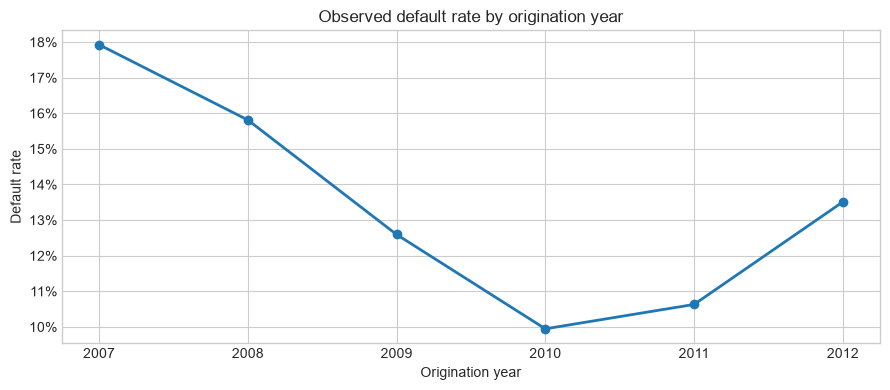

In [4]:
# Extract the calendar year so that loans can be compared and split through time.
loans["issue_year"] = loans["issue_date"].dt.year

# For each origination year, count loans and defaults and calculate the default rate.
year_summary = loans.groupby("issue_year")["default"].agg(
    loans="size", defaults="sum", default_rate="mean"
)
display(year_summary)

# Create a chart showing whether the observed default rate changes across vintages.
fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(year_summary.index, year_summary["default_rate"], marker="o", linewidth=2)
ax.set(title="Observed default rate by origination year", xlabel="Origination year", ylabel="Default rate")

# Format the vertical axis as percentages and display the completed chart.
ax.yaxis.set_major_formatter(lambda value, position: f"{value:.0%}")
plt.tight_layout()
plt.show()

## 2. Choose predictors and split in time

The target is

$$
D_i=\begin{cases}
1,&\text{loan }i\text{ defaults},\\
0,&\text{loan }i\text{ is fully paid}.
\end{cases}
$$

For \(n\) loans, collect the predictor information in a feature matrix

$$
X=
\begin{bmatrix}
x_{11} & x_{12} & \cdots & x_{1p}\\
x_{21} & x_{22} & \cdots & x_{2p}\\
\vdots & \vdots & \ddots & \vdots\\
x_{n1} & x_{n2} & \cdots & x_{np}
\end{bmatrix},
$$

and collect the observed outcomes in the target vector

$$
y=
\begin{bmatrix}
D_1 & D_2 & \cdots & D_n
\end{bmatrix}^{\!T}.
$$

Each **row of \(X\)** is one loan, each **column of \(X\)** is one predictor, and the corresponding entry of \(y\) records whether that loan ultimately defaulted.

The next code block only identifies these columns; it does not estimate the model yet:

| Python object | Statistical role | What happens later |
|---|---|---|
| `numeric_features` | Numerical columns of \(X\) | Missing values are replaced and columns are standardised |
| `categorical_features` | Label-based columns of \(X\) | Missing labels are replaced and categories become dummy variables |
| `features` | All columns used to construct \(X\) | Passed to the preprocessing and logistic-regression pipeline |
| `target` | The outcome vector \(y\) | Supplies the historical 0/1 default outcomes |

In Python, therefore,

```python
train[features]   # X_train: the information used to make predictions
train[target]     # y_train: the historical outcomes to be predicted
```
In mathematical notation:

$$\underbrace{X}_{\text{features}}
\quad\longrightarrow\quad
\underbrace{Y}_{\text{default target}}.$$


Keeping `default` out of `features` is essential. If the outcome were included among the predictors, the model would be given the answer it is supposed to learn—a direct form of target leakage.

We use a modest number of interpretable application variables. `grade` and `int_rate` already contain information from LendingClub's underwriting process, so this model partly **summarises the lender's existing assessment**. They are useful predictors, but their coefficients must not be interpreted causally.

In [5]:
# List numerical variables known when the loan was originated.
numeric_features = [
    "loan_amnt", "int_rate", "installment", "annual_inc", "dti",
    "delinq_2yrs", "inq_last_6mths", "open_acc", "pub_rec",
    "revol_bal", "revol_util", "total_acc",
]

# List categorical origination variables that will become dummy variables.
categorical_features = [
    "grade", "emp_length", "home_ownership", "verification_status",
    "purpose",
]

# Combine the predictor names and separately identify the outcome to predict.
features = numeric_features + categorical_features #The '+' joins the two Python lists.
target = "default" #The variable we want to predict is the default column

# Split chronologically: earlier loans teach the model; later loans test it.
# copy() keeps each subset independent of the original DataFrame.
train = loans.loc[loans["issue_year"] <= 2010].copy()
validation = loans.loc[loans["issue_year"] == 2011].copy()
test = loans.loc[loans["issue_year"] == 2012].copy()

# Summarise sample size and default frequency in each period.
split_summary = pd.DataFrame(
    {
        "Rows": [len(train), len(validation), len(test)],
        "Defaults": [train[target].sum(), validation[target].sum(), test[target].sum()],
        "Default rate": [train[target].mean(), validation[target].mean(), test[target].mean()],
    },
    index=["Train: 2007–2010", "Validation: 2011", "Test: 2012"],
)

# Format only the rate column as a percentage.
display(split_summary.style.format({"Default rate": "{:.2%}"}))

,Rows,Defaults,Default rate
Train: 2007–2010,14995,1728,11.52%
Validation: 2011,14101,1499,10.63%
Test: 2012,43344,5856,13.51%


## 3. Preprocessing is learned from training data only

The pipeline performs three operations:

1. replace missing numerical values with the training median;
2. standardise numerical variables so regularisation treats them comparably;
3. replace missing categories and create dummy variables.

### Numerical variables

If numerical value $x_{ij}$ is missing, replace it with the training-sample median of predictor $j$:

$$
x_{ij}^{*}=
\begin{cases}
x_{ij},&\text{if }x_{ij}\text{ is observed},\\
\operatorname{median}_{\text{train}}(x_j),&\text{if }x_{ij}\text{ is missing}.
\end{cases}
$$

The imputed value is then standardised:

$$
z_{ij}=\frac{x_{ij}^{*}-\mu_{j,\text{train}}}{\sigma_{j,\text{train}}},
$$

where $\mu_{j,\text{train}}$ and $\sigma_{j,\text{train}}$ are the training mean and standard deviation. Standardisation prevents the measurement units of numerical predictors from arbitrarily determining the strength of the L2 penalty. Dummy variables remain coded as 0 and 1.

### Categorical variables

A category becomes a 0/1 indicator. For example,

$$
I(\text{home ownership}=\text{RENT})=
\begin{cases}
1,&\text{if the borrower rents},\\
0,&\text{otherwise}.
\end{cases}
$$

One category is omitted as the reference group, preventing redundant dummy columns.

Calling `fit` learns these rules from the training rows. Calling `predict_proba` later applies the **same** medians, scales, and dummy-variable map to validation or test rows. This is how test data use the training transformations without being allowed to influence them.

In [6]:
def make_pd_model(C):
    # Build one complete preprocessing-and-logistic-regression pipeline.

    # Numerical preparation: replace missing values, then put variables on comparable scales.
    numeric_steps = Pipeline(
        [
            ("impute", SimpleImputer(strategy="median")),
            ("scale", StandardScaler()),
        ]
    )

    # Categorical preparation: replace missing labels, then create 0/1 dummy variables.
    categorical_steps = Pipeline(
        [
            ("impute", SimpleImputer(strategy="most_frequent")),
            (
                "dummies",
                # Drop one reference category and safely handle a new category later. 
                # sparse_output=False produces an ordinary dense numerical array.
                OneHotEncoder(drop="first", handle_unknown="ignore", sparse_output=False),
            ),
        ]
    )

    # Apply the numerical steps only to numerical columns and the categorical
    # steps only to categorical columns, then join the results side by side.
    preprocessing = ColumnTransformer(
        [
            ("numeric", numeric_steps, numeric_features),
            ("categorical", categorical_steps, categorical_features),
        ],
        verbose_feature_names_out=False, # Makes the resulting column names shorter and easier to read.
    )

    # Return one object that first prepares the rows and then estimates PD.
    # C controls regularisation; max_iter gives the optimiser enough iterations.
    return Pipeline(
        [
            ("prepare", preprocessing),
            ("pd_model",
               # Logistic regression uses L2/ridge regularisation;
               # smaller C means stronger coefficient shrinkage.
              LogisticRegression(C=C, max_iter=2_000)),
        ]
    )

## 4. Logistic regression produces a PD

### Connection to the earlier regularisation lecture

The earlier lecture added an L2 penalty to a linear regression:

$$
\min_{\beta_0,\beta}
\left\{
\sum_{i=1}^{n}(y_i-\beta_0-x_i^T\beta)^2
+\frac{\lambda}{2}\sum_{j=1}^{p}\beta_j^2
\right\}.
$$

That model was appropriate for a continuous outcome. Default is binary, so logistic regression replaces the squared-error fitting term with **Bernoulli log loss**. The L2 penalty and its purpose remain the same: it discourages unnecessarily large coefficients and trades a little additional bias for lower estimation variance. L2 is a natural choice here because several credit variables contain overlapping information and our objective is stable probability prediction rather than selecting a very short list of predictors.

For borrower characteristics $x_i$, logistic regression models

$$
\operatorname{logit}(PD_i)
=\ln\left(\frac{PD_i}{1-PD_i}\right)
=\beta_0+\beta_1x_{i1}+\cdots+\beta_kx_{ik}.
$$

Solving for the probability gives

$$
\widehat{PD}_i
=\frac{1}
{1+\exp[-(\widehat{\beta}_0+x_i^{T}\widehat{\beta})]}.
$$

The logistic transformation keeps every prediction between 0 and 1. We do **not** use class weights here: they can improve classification of the minority class but distort the raw probabilities unless the result is recalibrated.

To reduce overfitting, scikit-learn estimates a regularised model. A simplified L2-regularised objective is

$$
\min_{\beta}
\left\{
-\sum_{i=1}^{n}
\left[D_i\ln(PD_i)+(1-D_i)\ln(1-PD_i)\right]
+\frac{\lambda}{2}\sum_{j=1}^{p}\beta_j^2
\right\}.
$$

`C` is scikit-learn’s inverse regularisation-control parameter. A smaller `C` produces stronger L2 coefficient shrinkage.

Therefore,

$$
C\downarrow
\quad\Longleftrightarrow\quad
\text{stronger shrinkage, higher bias and lower variance}.
$$

A smaller `C` pulls coefficients more strongly toward zero, while a larger `C` allows the model to follow the training data more closely. We compare five values on a logarithmic scale using the 2011 validation vintage and select the one with the lowest Brier score. The 2012 test vintage remains untouched during this choice.

In [7]:
# Create empty containers for the validation statistics and fitted candidates.
validation_results = []

# Compare five regularisation strengths on a logarithmic scale.
# Including values on both sides of the eventual optimum avoids selecting an edge value.
for C in [0.01, 0.1, 1.0, 10.0, 100.0]:
    # Build and fit this candidate using the training years only.
    model = make_pd_model(C=C)
    model.fit(train[features], train[target])

    # Column 1 is P(default=1), which is the predicted PD for 2011 loans.
    validation_pd = model.predict_proba(validation[features])[:, 1] #predict.proba returns a 2D array with two columns: P(default=0) and P(default=1). We want the second column.

    # Calculate validation metrics
    # Record discrimination and probability-accuracy measures for this C.
    validation_results.append(
        {
            "C": C,
            "ROC AUC": roc_auc_score(
                validation[target], 
                validation_pd
                ),
            "Brier score": brier_score_loss(
                validation[target],
                  validation_pd
                  ),
            "Log loss": log_loss(
                validation[target],
                  validation_pd
                  ),
        }
    )
   

# Convert the collected dictionaries into one comparison table.
validation_results = pd.DataFrame(validation_results).set_index("C")
display(validation_results)

# Select C using Brier score because this notebook needs accurate probabilities.
best_C = validation_results[
    "Brier score"
    ].idxmin()
print(f"Selected C = {best_C:g}, using validation Brier score.")

,ROC AUC,Brier score,Log loss
C,,,
0.0100,0.6625,0.0919,0.3229
0.1000,0.6656,0.0918,0.3228
1.0000,0.6638,0.0920,0.3236
10.0000,0.6624,0.0921,0.3241
100.0000,0.6621,0.0921,0.3242


Selected C = 0.1, using validation Brier score.


## 5. Refit once, then evaluate once

After selecting the model form, we combine the earlier training and validation vintages, refit the model, and make one final set of predictions for the 2012 vintage. This is an **out-of-vintage retrospective evaluation**: later-originated loans do not influence model fitting or model selection, but the lifetime labels are observed after the loans resolve. It should not be described as a fully as-of-date deployment simulation.

In [8]:
# After model selection, combine the two earlier development vintages.
development = pd.concat(
    [train, validation],
      ignore_index=True
      )

# Rebuild the selected pipeline and refit it on the larger development sample using the selected C.
pd_model = make_pd_model(C=best_C)
pd_model.fit(development[features], development[target]) #new final logistic coefficients.

# Predict the untouched test vintage.
# Generate one out-of-time PD for every loan originated in 2012.
test_pd = pd_model.predict_proba(
    test[features]
    )[:, 1] 

# Calculate final test statistics. The 2012 outcomes were not used above.
test_metrics = pd.Series(
    {
        "ROC AUC": roc_auc_score(test[target], test_pd),
        "Brier score": brier_score_loss(test[target], test_pd),
        "Log loss": log_loss(test[target], test_pd),
        "Average predicted PD": test_pd.mean(),
        "Observed default rate": test[target].mean(),
    },
    name="2012 out-of-time test",
)

# Display the final test evidence in one column.
display(test_metrics.to_frame())

,2012 out-of-time test
ROC AUC,0.6458
Brier score,0.1136
Log loss,0.3814
Average predicted PD,0.1304
Observed default rate,0.1351


### Interpreting the test results

The model has modest ranking ability, with a test ROC AUC of approximately 0.65. Its average predicted PD of 13.04% is close to the observed default rate of 13.51%, which is encouraging for overall calibration. However, similar portfolio averages do not guarantee that the model is well calibrated across low- and high-risk borrowers. We examine this next using calibration groups.

### Discrimination and calibration answer different questions

Let $\widehat p_i=\widehat{PD}_i$ and let $D_i\in\{0,1\}$ be the observed outcome.

**ROC AUC** asks whether the model ranks a randomly selected default above a randomly selected non-default:

$$AUC=
P\left(\widehat p_{\text{default}}>
\widehat p_{\text{non-default}}\right)
+
\frac{1}{2}
P\left(\widehat p_{\text{default}}=
\widehat p_{\text{non-default}}\right).$$

It measures ranking, not whether the reported probabilities have the correct level.

#### How the ROC curve is constructed
`RocCurveDisplay.from_predictions` tries the distinct predicted PDs as classification thresholds. At threshold $c$, it temporarily labels a loan as a predicted default when

$$\widehat D_i(c)=I(\widehat p_i\geq c).$$
For every threshold, it calculates

$$TPR(c)=\frac{TP(c)}{TP(c)+FN(c)},
\qquad
FPR(c)=\frac{FP(c)}{FP(c)+TN(c)},$$

and plots $TPR(c)$ against $FPR(c)$. The area under this threshold curve is AUC. The dotted 45-degree line represents random ranking, where the true-positive rate rises no faster than the false-positive rate.

The ROC curve is a discrimination tool, not a calibration tool. It depends on the ordering of the PDs. A strictly increasing transformation can leave the ranking—and therefore ROC AUC—unchanged while making the reported probability levels too high or too low.

The **Brier score** is the mean squared probability error:

$$
\text{Brier}=\frac{1}{n}\sum_{i=1}^{n}(\widehat p_i-D_i)^2.
$$

The **log loss** is

$$
\text{Log loss}
=-\frac{1}{n}\sum_{i=1}^{n}
\left[D_i\ln(\widehat p_i)+(1-D_i)\ln(1-\widehat p_i)\right].
$$

Both are lower for more accurate probability forecasts, but log loss penalises a confident incorrect forecast especially strongly.

For calibration group $g$, the notebook compares

$$
\overline{PD}_g=\frac{1}{n_g}\sum_{i\in g}\widehat p_i
\qquad\text{with}\qquad
\widehat{DR}_g=\frac{1}{n_g}\sum_{i\in g}D_i.
$$

A well-calibrated model should have $\overline{PD}_g\approx\widehat{DR}_g$ across low- and high-risk groups.

A model can rank borrowers well and still report probabilities that are too high or too low. Therefore AUC alone is not enough for a PD model.

,loans,average_predicted_pd,observed_default_rate
PD band,,,
"(-0.001, 0.0508]",4335,3.91%,4.43%
"(0.0508, 0.0673]",4334,5.92%,6.71%
"(0.0673, 0.0841]",4334,7.56%,9.21%
"(0.0841, 0.101]",4335,9.24%,10.87%
"(0.101, 0.118]",4334,10.90%,11.74%
"(0.118, 0.136]",4334,12.65%,13.87%
"(0.136, 0.157]",4335,14.61%,15.82%
"(0.157, 0.186]",4334,17.04%,17.56%
"(0.186, 0.229]",4334,20.53%,20.93%


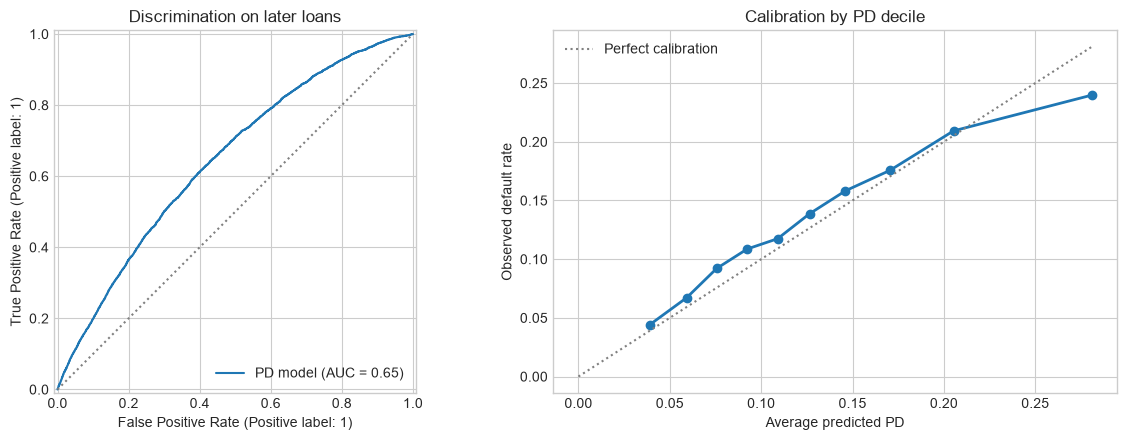

In [9]:
# Place every test prediction beside its realised 0/1 outcome.
calibration = pd.DataFrame(
    {
        "PD": test_pd,
        "Default": test[target].to_numpy()
        }
        )

# Sort loans into ten similarly sized groups from low predicted PD to high PD.
# pd.qcut(..., q=10) sorts borrowers by predicted PD and divides them into ten approximately equally sized groups.
calibration["PD band"] = pd.qcut(calibration["PD"], q=10, duplicates="drop")

# Within each band, compare average predicted PD with the observed default rate.
calibration_table = calibration.groupby("PD band", observed=True).agg(
    loans=("Default", "size"),
    average_predicted_pd=("PD", "mean"),
    observed_default_rate=("Default", "mean"),
)

# Show probabilities as percentages for easier interpretation.
display(calibration_table.style.format({
    "average_predicted_pd": "{:.2%}",
    "observed_default_rate": "{:.2%}",
}))

# Create two panels: ROC on the left and calibration on the right. 1-> axes[0] is the left panel, 2-> axes[1] is the right panel.
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

# Plot the ROC curve; the dotted diagonal represents random ranking.
RocCurveDisplay.from_predictions(
    test[target], 
    test_pd, 
    ax=axes[0], 
    name="PD model"
    )
axes[0].plot([0, 1], [0, 1], color="grey", linestyle=":")
axes[0].set_title("Discrimination on later loans")

# Plot observed default rates against average predicted PDs.
axes[1].plot(
    calibration_table["average_predicted_pd"], #The horizontal axis
    calibration_table["observed_default_rate"], #The vertical axis
    marker="o",
    linewidth=2,
)

# Use a common limit so that a 45-degree line represents perfect calibration.
limit = max(
    calibration_table["average_predicted_pd"].max(),
    calibration_table["observed_default_rate"].max(),
)
axes[1].plot([0, limit], [0, limit], color="grey", linestyle=":", label="Perfect calibration")
axes[1].set(
    title="Calibration by PD decile",
    xlabel="Average predicted PD",
    ylabel="Observed default rate",
)
axes[1].legend()

# Prevent labels from overlapping and display both panels.
plt.tight_layout()
plt.show()

### Interpreting the figures

The left panel shows **modest discrimination**. The ROC curve lies above the random-ranking line, and an AUC of approximately 0.65 means that the model generally assigns a higher predicted PD to a defaulting loan than to a non-defaulting loan, although the ranking is far from perfect.

The right panel shows that observed default rates generally increase as predicted PD increases. This indicates useful risk ordering. Calibration is reasonably close but not perfect: points above the 45-degree line indicate that the model **underpredicts** default risk, while points below the line indicate that it **overpredicts** default risk. In particular, the model underpredicts risk in several middle PD groups and overpredicts risk in the highest-PD group.

## 6. What has the model learned?

Each logistic coefficient changes the **log-odds** of default. Exponentiating a coefficient gives an odds multiplier. Numerical variables were standardised, so their odds multipliers correspond to a one-standard-deviation increase. Categorical effects are relative to the omitted reference category.

$$
\text{odds multiplier}=e^{\widehat\beta_j},
$$

so the associated percentage change in the odds is

$$
100\left(e^{\widehat\beta_j}-1\right)\%.
$$

For example, an odds multiplier of 1.20 corresponds to 20% higher estimated default odds, holding the other predictors fixed.

These are predictive associations, not causal effects. For example, changing the quoted interest rate would not mechanically create the full coefficient effect because the rate also reflects underwriting information.

The next block does not refit or change the model. The preprocessing step has expanded the original columns into a final design matrix containing standardised numerical variables and category indicators. `get_feature_names_out()` retrieves those prepared column names, while `coef_[0]` retrieves the fitted slope vector for the binary default model in the same order. Pairing the two tells us which coefficient belongs to which prepared predictor. The intercept is stored separately and is not shown.
Each number is one estimated $\widehat\beta_j$ in:

$$\operatorname{logit}(\widehat{PD}_i)
= \ln\left(
\frac{\widehat{PD}_i}
{1-\widehat{PD}_i}
\right)
=
\widehat\beta_0+
\widehat\beta_1z_{i1}
+\cdots+
\widehat\beta_pz_{ip}.$$

The table is sorted by $|\widehat\beta_j|$ only to bring the largest fitted coefficient magnitudes to the top. The original sign is retained: a positive coefficient has an odds multiplier above one, and a negative coefficient has an odds multiplier below one. Because numerical variables represent one-standard-deviation movements while dummy variables represent category-versus-reference comparisons, this ranking is descriptive—not a formal measure of feature importance, statistical significance or causality.

In [10]:
# Retrieve the names produced after imputation, scaling and dummy creation.
feature_names = pd_model.named_steps["prepare"].get_feature_names_out() #named_steps["prepare"] extracts the preprocessing component from the fitted pipeline we had earlier. get_feature_names_out() his returns the names of all columns in the processed design matrix.

# Match each fitted logistic coefficient to its prepared feature name.
coefficients = pd.Series(
    pd_model.named_steps["pd_model"].coef_[0], #This accesses the fitted logistic-regression component and returns its slope coefficients.
    index=feature_names,
    name="Coefficient",
)

# Exponentiating a coefficient converts a log-odds effect into an odds multiplier.
# Absolute coefficients are used only to sort the table by magnitude.
coefficient_table = pd.DataFrame(
    {
        "Coefficient": coefficients,
        "Odds multiplier": np.exp(coefficients), #Convert coefficients into odds multipliers
        "Change in odds (%)": 100 * (
            np.exp(coefficients) - 1
        ),
        "Absolute coefficient": coefficients.abs(),
    }
).sort_values("Absolute coefficient", ascending=False)


# Show the 15 largest fitted relationships, without the temporary sorting column.
display(coefficient_table
        .head(15)
        .drop(columns="Absolute coefficient")
        .round(3)
        )

,Coefficient,Odds multiplier,Change in odds (%)
purpose_small_business,0.6900,1.9940,99.3810
purpose_credit_card,-0.4210,0.6570,-34.3440
annual_inc,-0.4150,0.6600,-33.9610
int_rate,0.3550,1.4270,42.6560
purpose_moving,0.2820,1.3250,32.5220
purpose_renewable_energy,0.2630,1.3010,30.0880
purpose_wedding,-0.2530,0.7760,-22.3630
home_ownership_OTHER,0.2400,1.2710,27.0900
purpose_major_purchase,-0.2350,0.7910,-20.9340
grade_F,0.2240,1.2510,25.0960


In [11]:
# OneHotEncoder(drop="first", ...) removes the first category learned for each categorical variable. 
# The fitted encoder remembers this information in categories_ and drop_idx_.
# Retrieve the fitted one-hot encoder from the final PD pipeline.
fitted_onehot = (
    pd_model
    .named_steps["prepare"]
    .named_transformers_["categorical"]
    .named_steps["dummies"]
)

# Report the category omitted by drop="first" for each categorical variable.
reference_categories = pd.Series(
    {
        variable: categories[drop_index]
        for variable, categories, drop_index in zip(
            categorical_features,
            fitted_onehot.categories_,
            fitted_onehot.drop_idx_,
        )
    },
    name="Omitted reference category",
)

display(reference_categories.to_frame())

,Omitted reference category
grade,A
emp_length,1 year
home_ownership,MORTGAGE
verification_status,Not Verified
purpose,car


### Reading the fitted relationships

Several fitted relationships are economically intuitive:

- `purpose_small_business` has an odds multiplier of approximately 1.99. Holding the other predictors fixed, a small-business-purpose loan has almost twice the estimated default odds of an otherwise similar loan in the omitted purpose category, `car`.
- A one-standard-deviation increase in `annual_inc` is associated with approximately 34% lower default odds.
- A one-standard-deviation increase in `int_rate` is associated with approximately 43% higher default odds, while a one-standard-deviation increase in `inq_last_6mths` is associated with approximately 20% higher default odds.

An odds multiplier is not a probability multiplier. If an otherwise similar car-purpose loan had a PD of 10%, applying the small-business odds multiplier gives

$$
PD_{\text{small business}}
=
\frac{1.9938\times0.10}
{1-0.10+1.9938\times0.10}
\approx18.1\%,
$$

not 19.9% or 99%.

Categorical coefficients are always relative to their omitted reference categories. Numerical coefficients represent one-standard-deviation changes because those variables were standardised. The relationships are conditional on the other included predictors and have been shrunk by L2 regularisation.

Finally, the largest coefficient magnitude is not necessarily the most important portfolio-level predictor. Some large coefficients belong to uncommon categories, and overlapping variables such as `grade` and `int_rate` should be interpreted as conditional predictive associations—not causal effects or tests of statistical significance.

## 7. From PD to an illustrative lending rule

A 50% cutoff is usually meaningless in credit: a loan can be unattractive at a much smaller PD. Instead, compare expected gain and expected loss.

Let:

- \(m\) = profit margin if the loan performs, as a fraction of exposure;
- \(LGD\) = fraction of exposure lost if default occurs.

The simplified expected value per dollar is

$$
EV=(1-PD)m-PD\times LGD.
$$

Approve when \(EV>0\), which gives

$$
PD < \frac{m}{m+LGD}.
$$

The following assumptions are deliberately simple and are **not** a production pricing model. They show why a business cutoff must come from economics, not from classification convention.

In [12]:
# These are teaching assumptions, not values estimated from the data.
PROFIT_MARGIN_IF_GOOD = 0.12
LGD_ASSUMPTION = 0.55

# Solve (1 - PD) × margin - PD × LGD > 0 for the break-even PD.
economic_cutoff = PROFIT_MARGIN_IF_GOOD / (PROFIT_MARGIN_IF_GOOD + LGD_ASSUMPTION)

# Approve loans whose predicted PD lies below that illustrative cutoff.
approved = test_pd < economic_cutoff #test_pd contains the model’s predicted PDs for the 2012 test loans. This produces a Boolean array: True for approved loans and False for declined loans.

# Compare approval volume and realised default rates on the later test loans.
decision_summary = pd.Series(
    {
        "Illustrative PD cutoff": economic_cutoff,
        "Approval rate": approved.mean(), # Calculates the percentage approved because Python treats True as 1 and False as 0.
        "Observed default rate among approved loans": test.loc[approved, target].mean(), # Selects actual outcomes for approved loans. gives the observed default rate because default equals 1 for default and 0 otherwise.
        "Observed default rate among declined loans": test.loc[~approved, target].mean(), #selects declined loans; ~ means “not”.
    }
)

# Display all four results as percentages.
display(decision_summary.to_frame("Value").style.format("{:.2%}"))

,Value
Illustrative PD cutoff,17.91%
Approval rate,77.98%
Observed default rate among approved loans,11.06%
Observed default rate among declined loans,22.20%


The table shows that the illustrative lending rule creates a meaningful separation between lower- and higher-predicted-default-risk loans.
- PD cutoff = 17.91%: Approve a loan when its predicted PD is below 17.91%. This cutoff comes from the assumed 12% profit margin and 55% LGD.
- Approval rate = 77.98%: The rule would approve approximately 78 out of every 100 loans in the 2012 test sample.
- Approved-loan default rate = 11.06%: Among loans the rule would approve, about 11 out of 100 subsequently defaulted.
- Declined-loan default rate = 22.20%: Among loans the rule would decline, about 22 out of 100 subsequently defaulted.
The declined group’s default rate is approximately twice the approved group’s rate:

$$\frac{22.20\%}{11.06\%}\approx2.01.$$
The difference is:

$$22.20\%-11.06\%=11.14\text{ percentage points}.$$
Therefore, the main conclusion is:

The PD model and economic cutoff separate the loans into two groups with substantially different subsequent default rates. Loans that would be declined defaulted approximately twice as frequently as loans that would be approved.

However, this does not mean the model predicts every borrower correctly:

- $11.06\%$ of approved loans still defaulted.
- Most declined loans—$77.80\%$—did not default.

That is normal because PD is a probability, not a certain prediction.

Also, “declined” means would have been declined by our illustrative rule. These loans were actually funded historically, which is why their outcomes are available. This is a retrospective teaching exercise, not evidence of the profitability of a real lending policy. The fixed LGD and profit assumptions will be developed further in Notebook B.

## 8. Connect Notebook A to Notebook B

The next notebook combines PD with conditional LGD and EAD forecasts. Notebook A therefore creates an `outputs` folder and saves one row per 2012 test loan. Students do not need to create or edit this file. The true outcome is retained solely for later model evaluation.

In [13]:
# Create the hand-off folder if it does not already exist.
OUTPUT_DIR = Path("outputs")
OUTPUT_DIR.mkdir(exist_ok=True)

# Keep loan identity, date, original funded amount, realised outcome and PD forecast.
# funded_amnt is the amount funded at origination, not the EAD predicted in Notebook B.
pd_test_predictions = test[
    ["id", "issue_date", "funded_amnt", "default"]
].copy()

# Add the out-of-time PD forecast for each 2012 test loan.
pd_test_predictions["predicted_pd"] = test_pd

# Save one row per loan for Notebook B.
# index=False prevents the pandas row index from being saved.
pd_test_predictions.to_csv(
    OUTPUT_DIR / "pd_test_predictions.csv",
    index=False,
)

print(f"Saved {len(pd_test_predictions):,} test predictions.")

# Show a clean preview without displaying the pandas row index.
display(
    pd_test_predictions.head()
    .style
    .hide(axis="index")
    .format(
        {
            "funded_amnt": "${:,.0f}",
            "predicted_pd": "{:.2%}",
        }
    )
)

Saved 43,344 test predictions.


id,issue_date,funded_amnt,default,predicted_pd
438264,2012-01-01 00:00:00,"$32,875",0,6.09%
671149,2012-01-01 00:00:00,"$21,000",0,8.24%
675960,2012-01-01 00:00:00,"$5,000",0,5.61%
716762,2012-01-01 00:00:00,"$24,000",0,4.10%
788179,2012-01-01 00:00:00,"$7,600",0,3.17%


## 9. What an expert would still ask

This notebook is methodologically cleaner than a random split with a vague target, but it remains a teaching model.

1. **Horizon:** this is lifetime default over a 36-month contract, not regulatory 12-month PD.
2. **Sample Selection:** rejected applicants are absent, so the model applies to funded LendingClub loans—not all applicants. Therefore, the model learns $P(\text{default}\mid X,\text{funded}),$ not necessarily $P(\text{default}\mid X)$ for the entire population of applicants. This is the classic credit-scoring selection or reject-inference problem.

3. **Resolved-loan conditioning:** restricting to known outcomes can introduce survivorship or maturity bias.
4. **Dataset shift:** performance can change when underwriting, borrower mix, or the economy changes. The following can change through time:
  - lending standards;
  - macroeconomic conditions;
  - borrower composition;
  - interest rates; and
  - the screening process.

5. **Calibration drift:** PD calibration must be monitored and refreshed on new vintages.
6. **Feature governance:** `grade` and `int_rate` embed the lender's prior decision process and may not be available in another deployment.
7. **Fairness and regulation:** a production model needs legal review, explainability, stability tests, and fairness analysis.
8. **Outliers and functional form**: highly skewed variables such as annual income can create extreme predictions when entered linearly. A production model would examine transformations or caps learned from development data.

**Conclusion**

PD is a statement about default conditional on:

- the information available;
- the relevant population;
- the prediction horizon;
- when the model was estimated; and
- the economic environment.

Saying that “a borrower has a PD of 7%” is incomplete until we specify:

A 7% probability of what definition of default, over what horizon, estimated when, using what information, and for which population?